In [1]:
# ============================================================
# STEP 1: Upload File & Load Dataset
# ============================================================
import pandas as pd
import numpy as np
from google.colab import files

# Upload your CSV file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=== First 5 Rows ===")
print(df.head())

print("\n=== Shape (rows, columns) ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

Saving 2) Stock Prices Data Set.csv to 2) Stock Prices Data Set (1).csv
=== First 5 Rows ===
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391

=== Shape (rows, columns) ===
(497472, 7)

=== Data Types ===
symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

=== Missing Values ===
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

=== Basic Statistics ===
                open           high            low          close  \
count  497461.000000  497464.000000  497464.000000  497

In [2]:
# ============================================================
# STEP 2: Preprocess the Data
# ============================================================

# --- Filter to one stock (AAPL) for Simple Linear Regression ---
df_aapl = df[df['symbol'] == 'AAPL'].copy()
df_aapl = df_aapl.sort_values('date').reset_index(drop=True)

print(f"AAPL records: {len(df_aapl)}")
print(df_aapl.head())

# --- Handle missing values ---
print("\nMissing values before:")
print(df_aapl.isnull().sum())

df_aapl.fillna(df_aapl.mean(numeric_only=True), inplace=True)

print("\nMissing values after:")
print(df_aapl.isnull().sum())

# --- Feature Engineering ---
# We'll predict 'close' price using 'open' price (Simple Linear Regression = 1 feature)
# Also create a numeric day index for time-based regression

df_aapl['day_index'] = range(len(df_aapl))

print("\n=== Processed Dataset Sample ===")
print(df_aapl[['date', 'day_index', 'open', 'close']].head(10))

AAPL records: 1007
  symbol        date     open     high      low    close     volume
0   AAPL  2014-01-02  79.3828  79.5756  78.8601  79.0185   58791957
1   AAPL  2014-01-03  78.9799  79.0999  77.2042  77.2828   98303870
2   AAPL  2014-01-06  76.7785  78.1142  76.2285  77.7042  103359151
3   AAPL  2014-01-07  77.7599  77.9942  76.8464  77.1481   79432766
4   AAPL  2014-01-08  76.9728  77.9371  76.9556  77.6371   64686685

Missing values before:
symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Missing values after:
symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

=== Processed Dataset Sample ===
         date  day_index     open    close
0  2014-01-02          0  79.3828  79.0185
1  2014-01-03          1  78.9799  77.2828
2  2014-01-06          2  76.7785  77.7042
3  2014-01-07          3  77.7599  77.1481
4  2014-01-08          4  76.9728  77.6371
5  2014-01-09          5  78.1142  76.64

In [3]:
# ============================================================
# STEP 3: Train the Linear Regression Model
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# --- Define Feature (X) and Target (y) ---
# Simple Linear Regression: predicting 'close' from 'open'
X = df_aapl[['open']]   # single feature (2D array required by sklearn)
y = df_aapl['close']

print(f"Feature shape: {X.shape}")
print(f"Target shape:  {y.shape}")

# --- Train / Test Split (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# --- Train the Model ---
model = LinearRegression()
model.fit(X_train, y_train)

print("\n✅ Model trained successfully!")

Feature shape: (1007, 1)
Target shape:  (1007,)

Training samples : 805
Testing samples  : 202

✅ Model trained successfully!


In [4]:
# ============================================================
# STEP 4: Interpret Model Coefficients
# ============================================================

intercept  = model.intercept_
coefficient = model.coef_[0]

print("=" * 45)
print("       MODEL COEFFICIENTS")
print("=" * 45)
print(f"  Intercept  (β₀) : {intercept:.4f}")
print(f"  Coefficient (β₁): {coefficient:.4f}")
print("=" * 45)

print(f"""
📌 Interpretation:
   Regression Equation:
   Close Price = {intercept:.4f} + {coefficient:.4f} × Open Price

   → For every $1 increase in the OPENING price,
     the CLOSING price changes by ${coefficient:.4f}.

   → When the opening price is $0 (theoretical baseline),
     the predicted closing price would be ${intercept:.4f}.
""")

       MODEL COEFFICIENTS
  Intercept  (β₀) : 0.2057
  Coefficient (β₁): 0.9985

📌 Interpretation:
   Regression Equation:
   Close Price = 0.2057 + 0.9985 × Open Price

   → For every $1 increase in the OPENING price,
     the CLOSING price changes by $0.9985.

   → When the opening price is $0 (theoretical baseline),
     the predicted closing price would be $0.2057.



In [5]:
# ============================================================
# STEP 5: Evaluate the Model — R² and MSE
# ============================================================
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Make Predictions ---
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# --- Compute Metrics ---
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)

rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)

print("=" * 45)
print("         MODEL EVALUATION")
print("=" * 45)
print(f"  R² Score  — Train : {r2_train:.4f}")
print(f"  R² Score  — Test  : {r2_test:.4f}")
print("-" * 45)
print(f"  MSE       — Train : {mse_train:.4f}")
print(f"  MSE       — Test  : {mse_test:.4f}")
print(f"  RMSE      — Test  : {rmse_test:.4f}")
print(f"  MAE       — Test  : {mae_test:.4f}")
print("=" * 45)

print(f"""
📌 Interpretation:
   R² = {r2_test:.4f} → The model explains {r2_test*100:.2f}% of the
   variance in closing price using opening price.

   RMSE = {rmse_test:.4f} → On average, predictions are off
   by ±${rmse_test:.2f} from the actual closing price.
""")

         MODEL EVALUATION
  R² Score  — Train : 0.9972
  R² Score  — Test  : 0.9968
---------------------------------------------
  MSE       — Train : 1.7042
  MSE       — Test  : 1.8421
  RMSE      — Test  : 1.3572
  MAE       — Test  : 1.0111

📌 Interpretation:
   R² = 0.9968 → The model explains 99.68% of the
   variance in closing price using opening price.

   RMSE = 1.3572 → On average, predictions are off
   by ±$1.36 from the actual closing price.



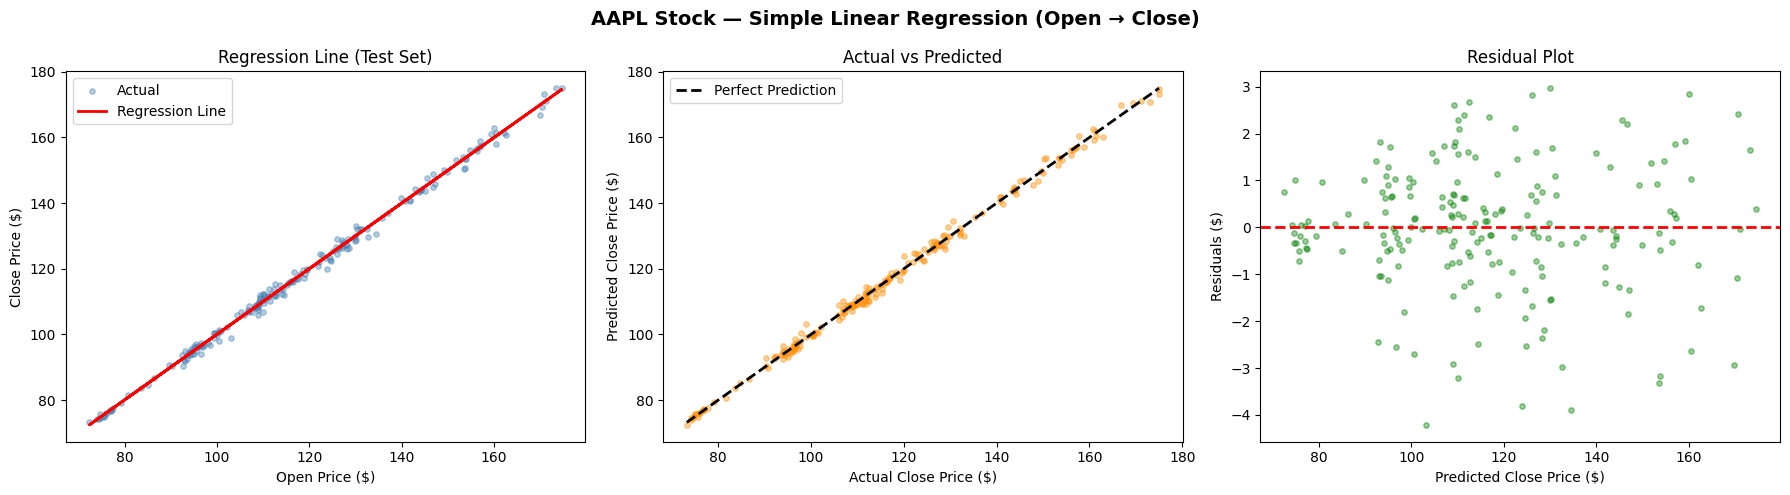

✅ Plot saved as 'linear_regression_results.png'


In [6]:
# ============================================================
# STEP 6: Visualize the Results
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AAPL Stock — Simple Linear Regression (Open → Close)', fontsize=14, fontweight='bold')

# --- Plot 1: Regression Line ---
axes[0].scatter(X_test, y_test, color='steelblue', alpha=0.4, s=15, label='Actual')
axes[0].plot(X_test, y_pred_test, color='red', linewidth=2, label='Regression Line')
axes[0].set_xlabel('Open Price ($)')
axes[0].set_ylabel('Close Price ($)')
axes[0].set_title('Regression Line (Test Set)')
axes[0].legend()

# --- Plot 2: Actual vs Predicted ---
axes[1].scatter(y_test, y_pred_test, color='darkorange', alpha=0.4, s=15)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Close Price ($)')
axes[1].set_ylabel('Predicted Close Price ($)')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

# --- Plot 3: Residuals ---
residuals = y_test - y_pred_test
axes[2].scatter(y_pred_test, residuals, color='green', alpha=0.4, s=15)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted Close Price ($)')
axes[2].set_ylabel('Residuals ($)')
axes[2].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as 'linear_regression_results.png'")

In [7]:
# ============================================================
# STEP 7: Final Summary
# ============================================================

print("=" * 50)
print("     TASK 2 COMPLETE — FINAL SUMMARY")
print("=" * 50)
print(f"  Dataset        : Stock Prices (AAPL subset)")
print(f"  Feature used   : Open Price")
print(f"  Target         : Close Price")
print(f"  Model          : Simple Linear Regression")
print(f"  Training rows  : {len(X_train)}")
print(f"  Testing rows   : {len(X_test)}")
print("-" * 50)
print(f"  Equation       : Close = {intercept:.3f} + {coefficient:.3f} × Open")
print(f"  R² (Test)      : {r2_test:.4f}  ({r2_test*100:.2f}% variance explained)")
print(f"  MSE (Test)     : {mse_test:.4f}")
print(f"  RMSE (Test)    : {rmse_test:.4f}")
print(f"  MAE (Test)     : {mae_test:.4f}")
print("=" * 50)
print("  Model is ready! ✅")

     TASK 2 COMPLETE — FINAL SUMMARY
  Dataset        : Stock Prices (AAPL subset)
  Feature used   : Open Price
  Target         : Close Price
  Model          : Simple Linear Regression
  Training rows  : 805
  Testing rows   : 202
--------------------------------------------------
  Equation       : Close = 0.206 + 0.999 × Open
  R² (Test)      : 0.9968  (99.68% variance explained)
  MSE (Test)     : 1.8421
  RMSE (Test)    : 1.3572
  MAE (Test)     : 1.0111
  Model is ready! ✅
